In [12]:
# intel_g2o_to_gbp.py
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple, Any, Optional
from IPython.display import clear_output

import numpy as np
import manifpy as m


import sys

PROJECT_ROOT = r"C:/Users/27118/Desktop/Imperial/abstraction-recovery/hierarchy_liegroup"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
# IMPORTANT: import from your gbp.py
from gbp.gbp import *
from utils.graphs import *

@dataclass
class G2OEdgeSE2:
    i: int
    j: int
    dx: float
    dy: float
    dtheta: float
    Omega: np.ndarray  # 3x3 information matrix


def _omega_from_upper_tri(vals6: List[float]) -> np.ndarray:
    """
    EDGE_SE2 line stores upper-triangular information matrix entries:
      I11 I12 I13 I22 I23 I33
    """
    I11, I12, I13, I22, I23, I33 = vals6
    return np.array(
        [
            [I11, I12, I13],
            [I12, I22, I23],
            [I13, I23, I33],
        ],
        dtype=float,
    )


def read_g2o_se2(path: str) -> Tuple[Dict[int, Tuple[float, float, float]], List[G2OEdgeSE2]]:
    """
    Read:
      VERTEX_SE2 id x y theta
      EDGE_SE2 i j dx dy dtheta I11 I12 I13 I22 I23 I33
    Return:
      vertices: {id: (x, y, theta)}  # initial guess in g2o
      edges: list with per-edge Omega
    """
    vertices: Dict[int, Tuple[float, float, float]] = {}
    edges: List[G2OEdgeSE2] = []

    with open(path, "r", encoding="utf-8") as f:
        for ln, line in enumerate(f, start=1):
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            tag = parts[0]

            if tag == "VERTEX_SE2":
                if len(parts) != 5:
                    raise ValueError(f"[line {ln}] bad VERTEX_SE2: {line}")
                vid = int(parts[1])
                x, y, th = map(float, parts[2:5])
                vertices[vid] = (x, y, th)

            elif tag == "EDGE_SE2":
                if len(parts) != 12:
                    raise ValueError(f"[line {ln}] bad EDGE_SE2: {line}")
                i = int(parts[1])
                j = int(parts[2])
                dx, dy, dth = map(float, parts[3:6])
                omega6 = list(map(float, parts[6:12]))
                Omega = _omega_from_upper_tri(omega6)
                edges.append(G2OEdgeSE2(i=i, j=j, dx=dx, dy=dy, dtheta=dth, Omega=Omega))

            else:
                # ignore other tags
                continue

    if not vertices:
        raise RuntimeError("No VERTEX_SE2 found. Is this a 2D pose-graph g2o file?")

    return vertices, edges


def build_gbp_from_intel_g2o(
    g2o_path: str,
    *,
    robustify: bool = False,
    anchor_id: Optional[int] = None,
    # anchor prior strength (only to fix gauge)
    anchor_sigma: Tuple[float, float, float] = (1e-3, 1e-3, 1e-5),
    # FactorGraph params
    nonlinear_factors: bool = True,
    eta_damping: float = 0.0,
    beta: float = 0.0,
    num_undamped_iters: int = 0,
    min_linear_iters: int = 10,
) -> Tuple[FactorGraph, List[Dict[str, Any]], List[Dict[str, Any]]]:
    """
    Output:
      fg: your gbp.py FactorGraph
      nodes_vis: cytoscape-like nodes list (data/id + position)
      edges_vis: cytoscape-like edges list (data/source/target/kind)
    Notes:
      - VERTEX_SE2 pose is treated as initial guess. We set v.status to it.
      - We also set v.GT = that pose (pseudo GT) to keep your loss/SE runnable.
      - Every EDGE_SE2 becomes an odometrySE2 factor with measurement_lambda = Omega.
      - Add a strong priorSE2 on anchor_id to remove gauge freedom.
      - Initialize messages exactly following your interface:
          v.to_factor_messages aligned with v.adj_factors
          f.to_variable_messages already exists, but we overwrite statuses for consistency
    """
    vertices, edges = read_g2o_se2(g2o_path)

    if anchor_id is None:
        anchor_id = min(vertices.keys())

    # Create graph
    fg = FactorGraph(
        nonlinear_factors=nonlinear_factors,
        eta_damping=eta_damping,
        beta=beta,
        num_undamped_iters=num_undamped_iters,
        min_linear_iters=min_linear_iters,
    )

    # Build variable nodes (keep original IDs)
    id_list = sorted(vertices.keys())
    id_to_v: Dict[int, VariableNode] = {}

    nodes_vis: List[Dict[str, Any]] = []
    for vid in id_list:
        x, y, th = vertices[vid]
        v = VariableNode(variable_id=vid, dofs=3)
        v.status = m.SE2(x, y, th)
        v.Lam = np.eye(3) * 1e-6  # small info to keep SE2 operations well-defined
        v.GT = m.SE2(x, y, th)  # pseudo GT = initial (since true GT not in g2o)
        fg.var_nodes.append(v)
        id_to_v[vid] = v

        nodes_vis.append(
            {
                "data": {"id": str(vid), "dim": 3, "theta": float(th)},
                "position": {"x": float(x), "y": float(y)},
            }
        )

    fg.n_var_nodes = len(fg.var_nodes)

    # Add anchor prior (factor 0)
    ax, ay, ath = vertices[anchor_id]
    z_anchor = m.SE2(ax, ay, ath)
    sig = np.array(anchor_sigma, dtype=float)
    Lam_anchor = np.diag(1.0 / (sig ** 2))

    factors: List[Any] = []
    f_id = 0

    f0 = priorSE2(
        factor_id=f_id,
        adj_var_nodes=[id_to_v[anchor_id]],
        measurement=z_anchor,
        measurement_lambda=Lam_anchor,
        robustify=robustify,
    )
    factors.append(f0)
    f_id += 1

    edges_vis: List[Dict[str, Any]] = []
    # Add all between edges
    for e in edges:
        if e.i not in id_to_v or e.j not in id_to_v:
            continue
        z_ij = m.SE2(e.dx, e.dy, e.dtheta)

        f = odometrySE2(
            factor_id=f_id,
            adj_var_nodes=[id_to_v[e.i], id_to_v[e.j]],
            measurement=z_ij,
            measurement_lambda=e.Omega,   # IMPORTANT: use g2o per-edge Omega
            robustify=robustify,
        )
        factors.append(f)

        kind = "odom" if (e.j == e.i + 1) else "loop"
        edges_vis.append({"data": {"source": str(e.i), "target": str(e.j), "kind": kind}})

        f_id += 1

    # Register factors into graph and build adjacency: v.adj_factors
    fg.factors = factors
    fg.n_factor_nodes = len(fg.factors)

    for f in fg.factors:
        for v in f.adj_var_nodes:
            v.adj_factors.append(f)

    # ----------- Linearize once -----------
    for f in fg.factors:
        f.linpoints = [v.status for v in f.adj_var_nodes]
        f.update_factor()

    # ----------- Initialize Messages (EXACTLY your interface) -----------
    # Var -> Factor messages
    for v in fg.var_nodes:
        v.to_factor_messages = []
        for _f in v.adj_factors:
            v.to_factor_messages.append(Message(status=v.status))  # small info to keep SE2 operations well-defined

    # Factor -> Var messages
    for f in fg.factors:
        # f.to_variable_messages already exists from Factor.__init__ (status=adj_var_node.status),
        # but we overwrite status explicitly for consistency:
        f.to_variable_messages = []
        for v in f.adj_var_nodes:
            f.to_variable_messages.append(Message(status=v.status))  # small info to keep SE2 operations well-defined

    return fg, nodes_vis, edges_vis


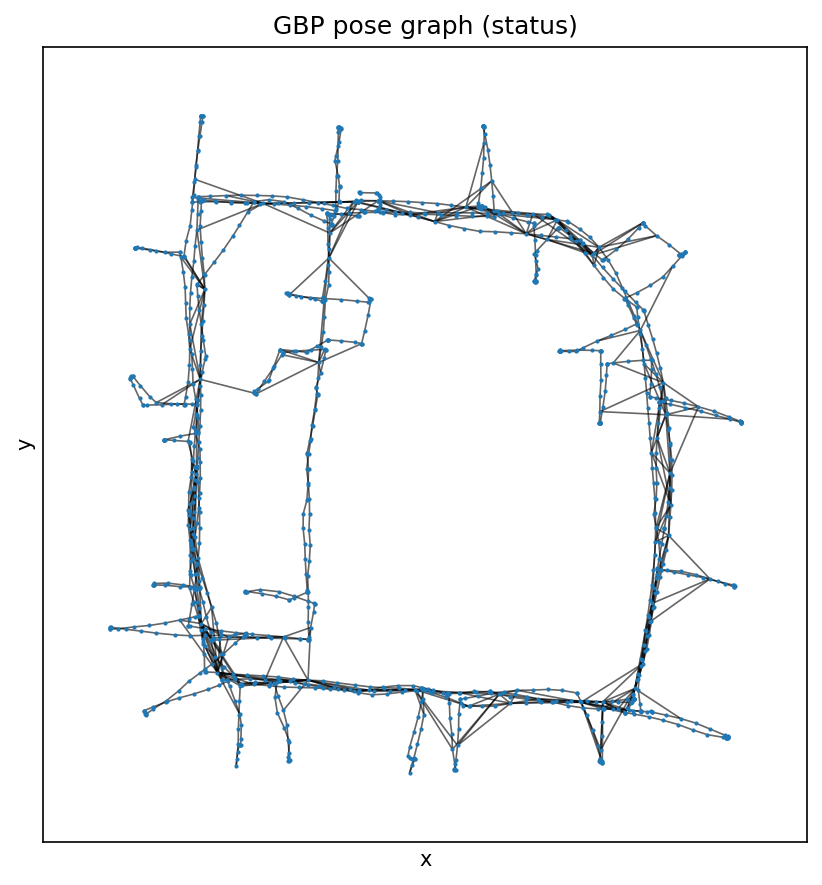

77 111.58661275830933
0.006792395206776793 -0.0038278974556682837 0.0001213562104472895


KeyboardInterrupt: 

In [14]:

fg, nodes, edges = build_gbp_from_intel_g2o("C:/Users/27118/Desktop/Imperial/abstraction-recovery/hierarchy_liegroup/tests/input_INTEL_g2o.txt", 
                num_undamped_iters=1,
                min_linear_iters=1,
                eta_damping=0,
                robustify=False)



plot_gbp_graph_xy(
    fg, edges,     
    s=1,
    figsize=(8, 6),        # NEW: figure size in inches
    dpi=150, show_ids=False, id_font_size=5)

prev_loss = fg.loss()
coutnter = 0
epsilon = 1e-3

"""
for i in range(fg.n_var_nodes):
    for factor in fg.var_nodes[i].adj_factors:
        factor.compute_messages()

    fg.var_nodes[i].update_belief()

print(fg.var_nodes[1].status.translation()[0], fg.var_nodes[1].status.translation()[1], fg.var_nodes[1].status.angle())


for j in range(fg.n_var_nodes):
    i = fg.n_var_nodes - j - 1
    for factor in fg.var_nodes[i].adj_factors:
        factor.compute_messages()
    fg.var_nodes[i].update_belief() 
"""

for iter in range(1000):
    for i in range(fg.n_var_nodes):
        for factor in fg.var_nodes[i].adj_factors:
            factor.compute_messages()
        fg.var_nodes[i].update_belief()

    print(fg.var_nodes[1].status.translation()[0], fg.var_nodes[1].status.translation()[1], fg.var_nodes[1].status.angle())



    for j in range(fg.n_var_nodes):
        i = fg.n_var_nodes - j - 1
        for factor in fg.var_nodes[i].adj_factors:
            factor.compute_messages()
        fg.var_nodes[i].update_belief() 


    #fg.synchronous_iteration()
    print(fg.var_nodes[1].status.translation()[0], fg.var_nodes[1].status.translation()[1], fg.var_nodes[1].status.angle())
    loss = fg.loss()

    if abs(prev_loss - loss) < epsilon:
        coutnter += 1
    else:
        coutnter = 0

    if coutnter >= 3:
        print(f"Early stopping at iter {iter} due to convergence (loss change < {epsilon} for 3 iters).")
        break

    fg.relinearise_factors()

    if iter % 1 == 0:
        clear_output(wait=True)
        plot_gbp_graph_xy(
            fg, edges,     
            s=1,
            figsize=(8, 6),        # NEW: figure size in inches
            dpi=150, show_ids=False, id_font_size=5)
        
    print(iter, loss)
    prev_loss = loss

    

In [23]:
mu, Sigma = fg.joint_distribution_cov()

fg.var_nodes[1].status += m.SE2Tangent(mu[3:6])

print(fg.var_nodes[1].status.translation()[0], fg.var_nodes[1].status.translation()[1], fg.var_nodes[1].status.angle())

-1.2318718399361578e-06 2.2139704032369742e-07 -0.0006419759632771668


In [ ]:
fg.min_linear_iters = 10
fg.relinearise_factors()
for iter in range(1000):
    fg.synchronous_iteration()

    print(fg.var_nodes[1].status.translation()[0], fg.var_nodes[1].status.translation()[1], fg.var_nodes[1].status.angle())

    print(fg.loss())


0.00957025964008912 -0.003508401956110165 -1.7632834925688865e-05
131.7768661465152
0.009562409931332342 -0.0035081229260467257 -1.8137695772476464e-05
417.55785742432687
0.009552879418082694 -0.0035078494244908153 -1.8878354599632577e-05
9994.832971318481
0.009541758820964226 -0.00350758091333605 -1.9648360839520474e-05
198.47946996956549
0.009517251742590478 -0.003507294172217567 -1.9014988407098746e-05
3352.8308117754414
0.009499253543765284 -0.0035070660388278538 -1.8632409761227913e-05
121.7156076524246
0.00948123532900034 -0.0035070766618092346 -1.9450555773571555e-05
458.8660962270295
0.009457583789089789 -0.003507222842463549 -2.1090016325333493e-05
478.2665566936029
0.00943017358147681 -0.003507108197202042 -2.2236162657361957e-05
243.39390975293085
0.0094055439531299 -0.0035064980259764066 -2.222403810102012e-05
197.04611691077352
0.009391942734197864 -0.003506345778188293 -2.261243432664543e-05
583.9003895049892
0.00937612082243531 -0.003506525143153199 -2.3408577445865708e-

KeyboardInterrupt: 

: 

In [19]:
for f in fg.factors:
    if fg.var_nodes[1118] in f.adj_var_nodes:
        print(f.factorID, f.loss(), [var.variableID for var in f.adj_var_nodes], f.measurement_lambda)

1118 2030471694.2499225 [1117, 1118] [[ 9.87546747e+05 -4.33604514e+06  0.00000000e+00]
 [-4.33604514e+06  1.90386025e+07  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  9.62681493e+02]]
1119 1002295308.3963957 [1118, 1119] [[ 3.68477952e+05 -1.99062395e+06  0.00000000e+00]
 [-1.99062395e+06  1.07542589e+07  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.21398976e+03]]


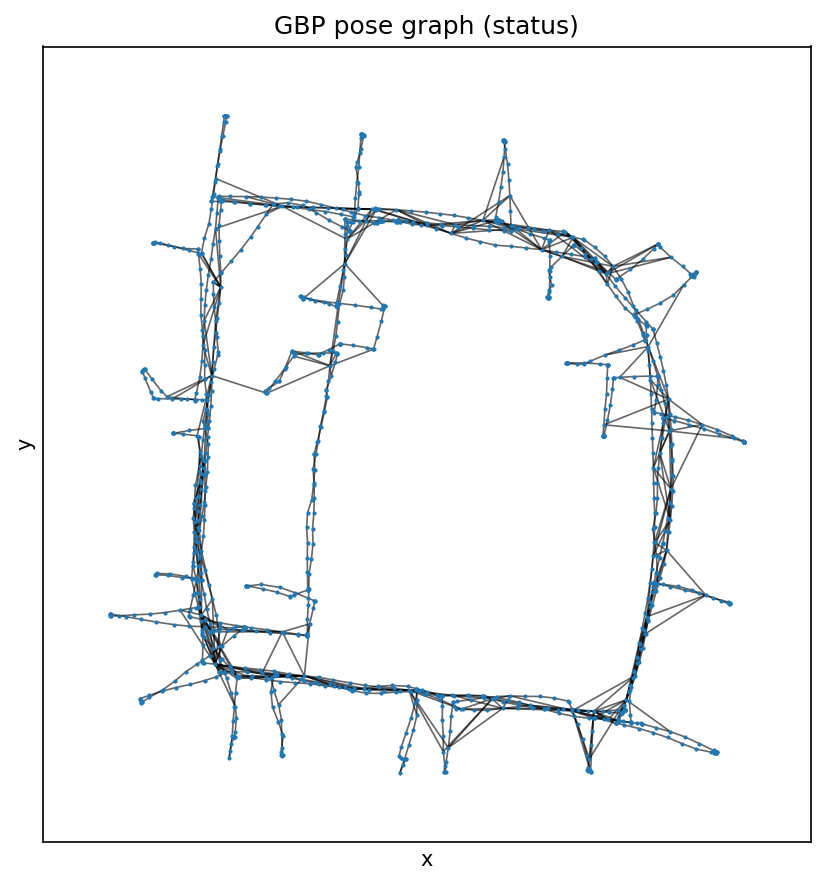

after iteration  14  loss:  107.91906862074718  SE:  496622.74677507975
Converged after iteration  15


In [8]:
prev_loss = 1e10
threshold = 1e-4
counter = 0
damped_coefficient = 0.5
loss = fg.loss()
print("before iteration ", " loss: ", loss, " SE: ", fg.SE())  

clear_output(wait=True)
plot_gbp_graph_xy(
    fg, edges,     
    s=1,
    figsize=(8, 6),        # NEW: figure size in inches
    dpi=150)

time.sleep(5)  # NEW: add a small delay to better visualize convergence
for j in range(50):
    mu, Sigma = fg.joint_distribution_cov()

    for i, v in enumerate(fg.var_nodes):
        fg.var_nodes[i].status += damped_coefficient* m.SE2Tangent(mu[3*i], mu[3*i+1], mu[3*i+2])

    for f in fg.factors:
        f.linpoints = [vn.status for vn in f.adj_var_nodes]
        f.update_factor()
        
    loss = fg.loss()

    if abs(prev_loss - loss) < threshold:
        counter += 1
    else:
        counter = 0

    if counter >= 3:
        print("Converged after iteration ", j+1)
        break   

    clear_output(wait=True)
    plot_gbp_graph_xy(
        fg, edges,     
        s=1,
        figsize=(8, 6),        # NEW: figure size in inches
        dpi=150)
    time.sleep(5)  # NEW: add a small delay to better visualize convergence

    print("after iteration ", j+1, " loss: ", loss, " SE: ", fg.SE())   

    prev_loss = loss

In [8]:
print(fg.var_nodes[160].status.translation()[0], fg.var_nodes[160].status.translation()[1], fg.var_nodes[160].status.angle())
print(fg.var_nodes[161].status.translation()[0], fg.var_nodes[161].status.translation()[1], fg.var_nodes[161].status.angle())

-0.7750994516356468 -9.724965015037519 2.5747017591244203
-0.7669829688612657 -9.76813541517782 -2.9929105020388893


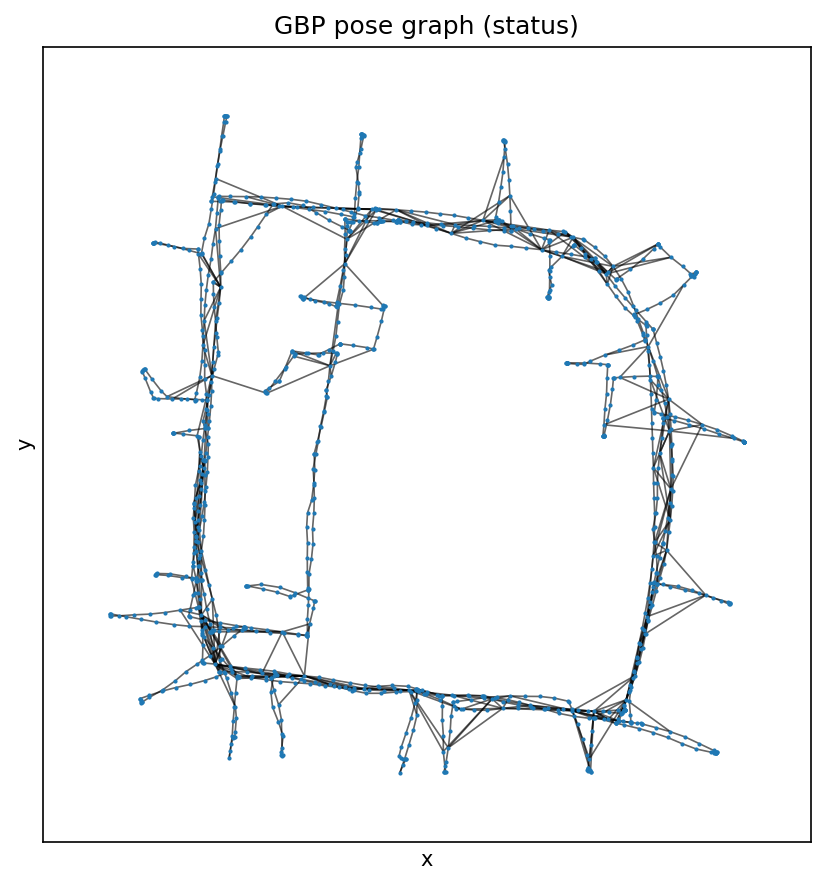

after iteration  25  loss:  107.91906433601162  SE:  496626.119992456
Converged after iteration  26


In [23]:
fg2, nodes, edges = build_gbp_from_intel_g2o("C:/Users/27118/Desktop/Imperial/abstraction-recovery/hierarchy_liegroup/tests/input_INTEL_g2o.txt", 
                num_undamped_iters=4,
                min_linear_iters=5,
                eta_damping=0.2,
                robustify=False)

prev_loss = 1e10
threshold = 1e-4
counter = 0
damped_coefficient = 0.5
loss = fg2.loss()
print("before iteration ", " loss: ", loss, " SE: ", fg2.SE())  

clear_output(wait=True)
plot_gbp_graph_xy(
    fg2, edges,     
    s=1,
    figsize=(8, 6),        # NEW: figure size in inches
    dpi=150)

for j in range(50):
    mu, Sigma = fg2.joint_distribution_cov()

    for i, v in enumerate(fg2.var_nodes):
        fg2.var_nodes[i].status += damped_coefficient* m.SE2Tangent(mu[3*i], mu[3*i+1], mu[3*i+2])

    for f in fg2.factors:
        f.linpoints = [vn.status for vn in f.adj_var_nodes]
        f.update_factor()
        
    loss = fg2.loss()

    if abs(prev_loss - loss) < threshold:
        counter += 1
    else:
        counter = 0

    if counter >= 3:
        print("Converged after iteration ", j+1)
        break   

    clear_output(wait=True)
    plot_gbp_graph_xy(
        fg2, edges,     
        s=1,
        figsize=(8, 6),        # NEW: figure size in inches
        dpi=150)
    time.sleep(0)  # NEW: add a small delay to better visualize convergence

    print("after iteration ", j+1, " loss: ", loss, " SE: ", fg2.SE())   

    prev_loss = loss

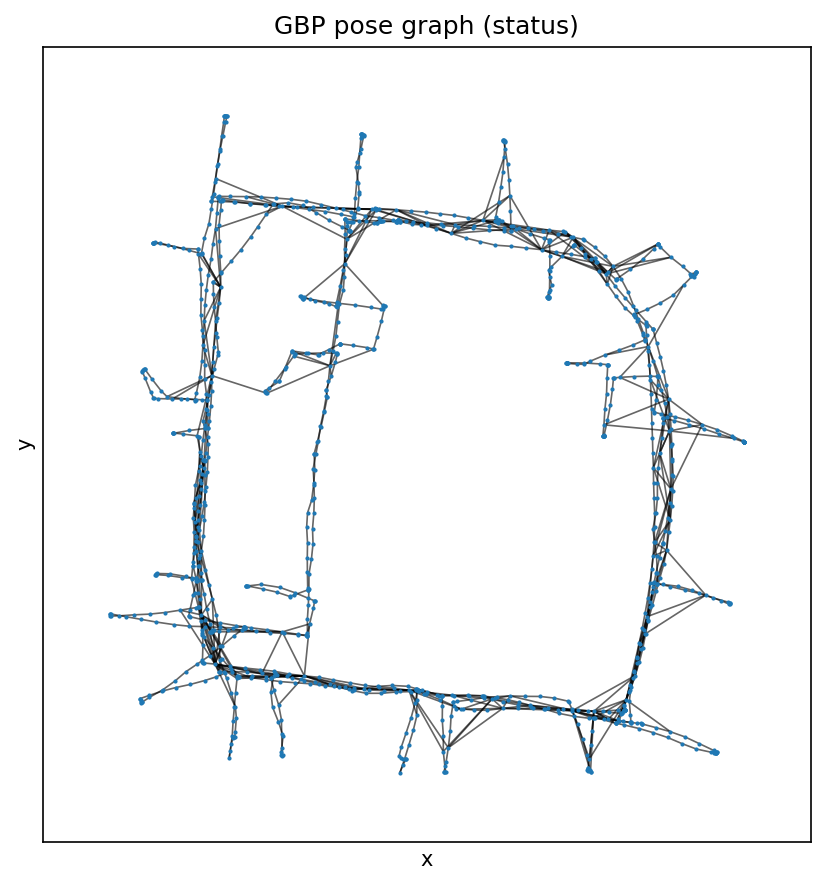

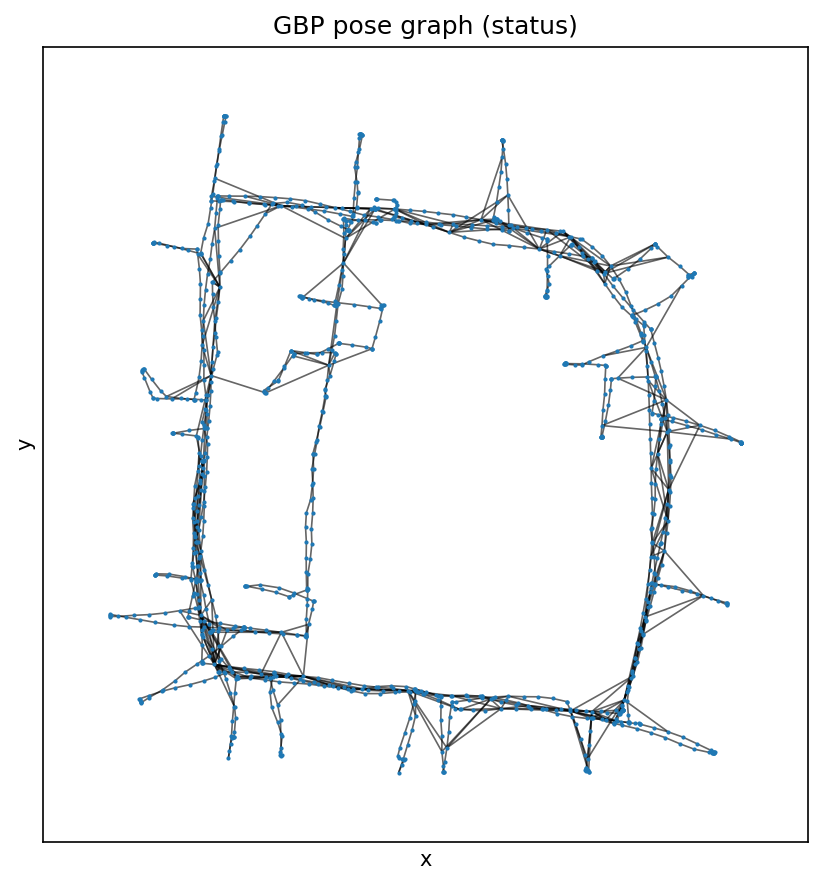

In [ ]:
import numpy as np

def fit_SE2(P, Q):
    # P,Q: (N,2)
    Pc = P - P.mean(0)
    Qc = Q - Q.mean(0)
    H = Pc.T @ Qc
    U,S,Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1,:] *= -1
        R = Vt.T @ U.T
    t = Q.mean(0) - (R @ P.mean(0))
    return R, t

def apply_SE2(P, R, t):
    return (P @ R.T) + t


P = np.zeros((fg.n_var_nodes,2))
Q = np.zeros_like(P)
for i, v in enumerate(fg.var_nodes):
    P[i] = [v.status.translation()[0], v.status.translation()[1]]

for i, v in enumerate(fg2.var_nodes):
    Q[i] = [v.status.translation()[0], v.status.translation()[1]]

R, t = fit_SE2(P, Q)
Q_aligned = apply_SE2(P, R, t)

for i, v in enumerate(fg.var_nodes):
    v.status = m.SE2(Q_aligned[i,0], Q_aligned[i,1], v.status.angle())


plot_gbp_graph_xy(
    fg2, edges,     
    s=1,
    figsize=(8, 6),        # NEW: figure size in inches
    dpi=150)


plot_gbp_graph_xy(
    fg, edges,     
    s=1,
    figsize=(8, 6),        # NEW: figure size in inches
    dpi=150)


In [25]:
np.sum((Q-Q_aligned)**2)

np.float64(10.909986056907135)

In [86]:
for adj_factor in fg.var_nodes[1].adj_factors:
    print(adj_factor.factorID, adj_factor.loss(), [var.variableID for var in adj_factor.adj_var_nodes])

fg.factors[1].compute_messages()
print(fg.factors[1].to_variable_messages[1].Lam, fg.factors[1].to_variable_messages[1].status.translation()[0], fg.factors[1].to_variable_messages[1].status.translation()[1], fg.factors[1].to_variable_messages[1].status.angle())
print(fg.factors[2].to_variable_messages[0].Lam, fg.factors[2].to_variable_messages[0].status.translation()[0], fg.factors[2].to_variable_messages[0].status.translation()[1], fg.factors[2].to_variable_messages[0].status.angle())
fg.var_nodes[1].update_belief()
fg.var_nodes[0].update_belief()

print(fg.var_nodes[1].status.translation()[0], fg.var_nodes[1].status.translation()[1], fg.var_nodes[1].status.angle())
fg.factors[1].loss()

1 0.008051475079257362 [0, 1]
2 371.0321713039037 [1, 2]
[[ 1.11112718e+01 -2.49667017e-01 -4.12453590e-06]
 [-2.49667017e-01  3.99999867e+02  8.58233338e-05]
 [-4.12453590e-06  8.58233338e-05  2.49679309e+03]] 3.8706668079036e-12 -7.584150321648941e-13 -0.0006419999999997438
[[8.83822830e-01 8.54723915e-02 6.72096688e-02]
 [8.54723900e-02 1.90554857e+00 1.66898754e+00]
 [6.72096679e-02 1.66898754e+00 7.14211489e+01]] 0.15786483756762407 -0.8914892566419298 0.044157850321409134
0.007011521032809222 -0.00402479195191502 -3.265634059755056e-06


np.float64(0.0080514750792549)

In [41]:
print(fg.var_nodes[1].status.translation()[0], fg.var_nodes[1].status.translation()[1], fg.var_nodes[1].status.angle())
print(fg2.var_nodes[1].status.translation()[0], fg2.var_nodes[1].status.translation()[1], fg2.var_nodes[1].status.angle())


print(fg.var_nodes[10].status.translation()[0], fg.var_nodes[10].status.translation()[1], fg.var_nodes[10].status.angle())
print(fg2.var_nodes[10].status.translation()[0], fg2.var_nodes[10].status.translation()[1], fg2.var_nodes[10].status.angle())


print(fg.var_nodes[10].status.translation()[0], fg.var_nodes[10].status.translation()[1], fg.var_nodes[10].status.angle())
print(fg2.var_nodes[10].status.translation()[0], fg2.var_nodes[10].status.translation()[1], fg2.var_nodes[10].status.angle())

-0.11873131449869473 0.963190033266714 -3.2656320675409704e-06
-1.1081862680060147e-08 -8.0311430379792e-09 -0.0006420007563700498
0.6377707431152227 0.5620148665308335 2.9257332219828163
0.7289810671992257 0.04321989186150175 2.905515307022746
0.6377707431152227 0.5620148665308335 2.9257332219828163
0.7289810671992257 0.04321989186150175 2.905515307022746


array([[-5.46162345e+05,  3.04727150e+06,  4.59625157e-01],
       [-8.45543955e+04,  4.71701120e+05,  7.11468389e-02],
       [-5.30340579e+03,  2.95896032e+04,  7.73953550e+02]])